1.Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Statistics
from scipy.stats import zscore

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# PCA
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

2. Load Dataset

In [2]:
df = pd.read_csv("/content/heart.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


3. Basic EDA

In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

Target Distribution

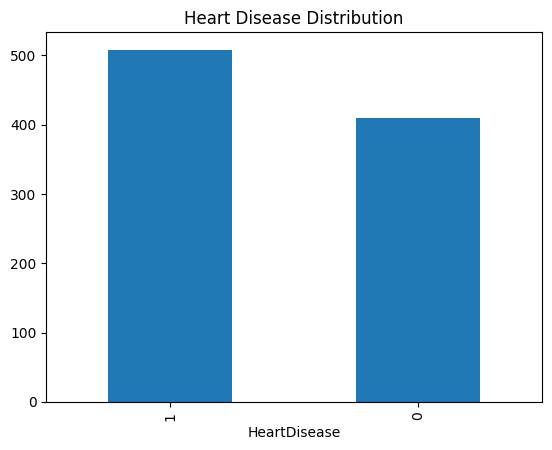

In [4]:
df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")

plt.show()

4. Remove Outliers

In [5]:
numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

numeric_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Z-score

In [6]:
z_scores = df[numeric_cols].apply(zscore)

Remove Outliers

In [7]:
df_clean = df[
    (z_scores.abs() < 3).all(axis=1)
]

print("Original Shape:", df.shape)

print("After Outlier Removal:",
      df_clean.shape)

print("Rows Removed:",
      len(df) - len(df_clean))

Original Shape: (918, 12)
After Outlier Removal: (899, 12)
Rows Removed: 19


5. Encode Categorical Columns

In [8]:
categorical_cols = df_clean.select_dtypes(
    include=['object']
).columns

print(categorical_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


Label Encoding

In [9]:
le = LabelEncoder()

for col in categorical_cols:

    df_clean.loc[:, col] = (
        le.fit_transform(df_clean[col])
    )

6. Define Features & Target

In [10]:
X = df_clean.drop(
    "HeartDisease",
    axis=1
)

y = df_clean["HeartDisease"]

7. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

8. Scale Continuous Features

In [12]:
continuous_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

Create Copies

In [13]:
X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

Scale

In [14]:
scaler = StandardScaler()

X_train_scaled[continuous_cols] = (
    scaler.fit_transform(
        X_train[continuous_cols]
    )
)

X_test_scaled[continuous_cols] = (
    scaler.transform(
        X_test[continuous_cols]
    )
)

9. Logistic Regression

In [15]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr.predict(
    X_test_scaled
)

lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Accuracy:",
      lr_acc)

Logistic Accuracy: 0.8611111111111112


10. SVM

In [16]:
svm = SVC(
    kernel='rbf',
    probability=True
)

svm.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm.predict(
    X_test_scaled
)

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:",
      svm_acc)

SVM Accuracy: 0.8888888888888888


11. Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

print("RF Accuracy:",
      rf_acc)

RF Accuracy: 0.8833333333333333


12. Compare Baseline Models

In [18]:
results_before = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        lr_acc,
        svm_acc,
        rf_acc
    ]
})

results_before

,Model,Accuracy
0,Logistic Regression,0.861111
1,SVM,0.888889
2,Random Forest,0.883333


Visualization

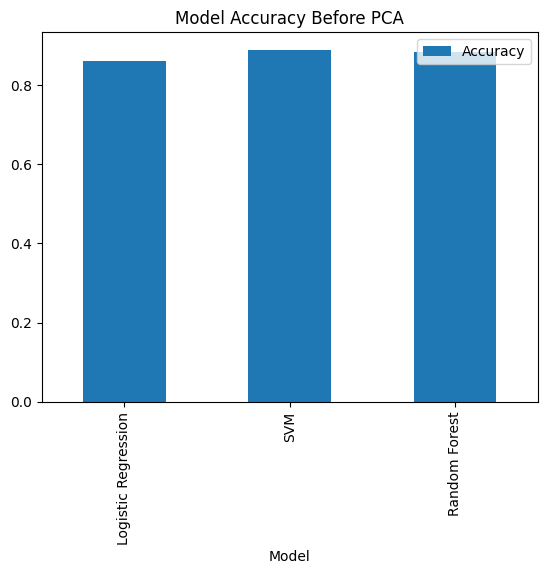

In [19]:
results_before.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title(
    "Model Accuracy Before PCA"
)

plt.show()

13. Apply PCA

Preserve 95% Variance


In [20]:
pca = PCA(
    n_components=0.95
)

Fit PCA

In [21]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

Check Reduction

In [22]:
print(
    "Original Features:",
    X_train.shape[1]
)

print(
    "Reduced Features:",
    X_train_pca.shape[1]
)

print(
    "Variance Retained:",
    sum(
        pca.explained_variance_ratio_
    )
)

Original Features: 11
Reduced Features: 9
Variance Retained: 0.9608250101147431


14. PCA Explained Variance

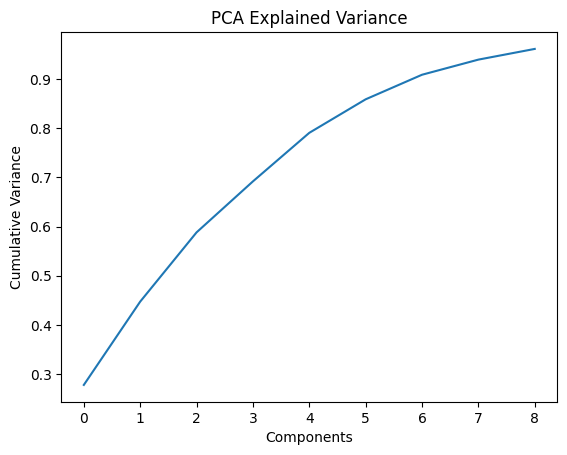

In [23]:
plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Components")

plt.ylabel(
    "Cumulative Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.show()

15. Train Models After PCA

Logistic

In [24]:
lr_pca = LogisticRegression(
    max_iter=1000
)

lr_pca.fit(
    X_train_pca,
    y_train
)

lr_pca_acc = accuracy_score(
    y_test,
    lr_pca.predict(X_test_pca)
)

SVM

In [25]:
svm_pca = SVC()

svm_pca.fit(
    X_train_pca,
    y_train
)

svm_pca_acc = accuracy_score(
    y_test,
    svm_pca.predict(X_test_pca)
)

Random Forest

In [26]:
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_pca.fit(
    X_train_pca,
    y_train
)

rf_pca_acc = accuracy_score(
    y_test,
    rf_pca.predict(X_test_pca)
)

16. Compare Before vs After PCA

In [27]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Before",
        "Logistic After",
        "SVM Before",
        "SVM After",
        "RF Before",
        "RF After"
    ],

    "Accuracy":[
        lr_acc,
        lr_pca_acc,
        svm_acc,
        svm_pca_acc,
        rf_acc,
        rf_pca_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Before,0.861111
1,Logistic After,0.866667
2,SVM Before,0.888889
3,SVM After,0.883333
4,RF Before,0.883333
5,RF After,0.883333


Visualization

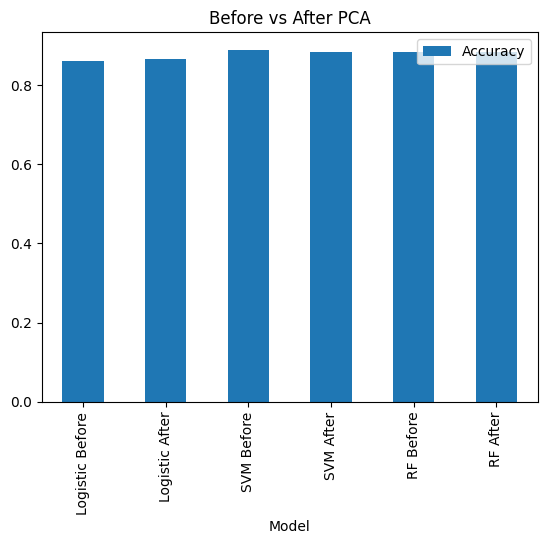

In [28]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title(
    "Before vs After PCA"
)

plt.show()

17. Confusion Matrix

In [29]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm)

[[69 12]
 [ 9 90]]


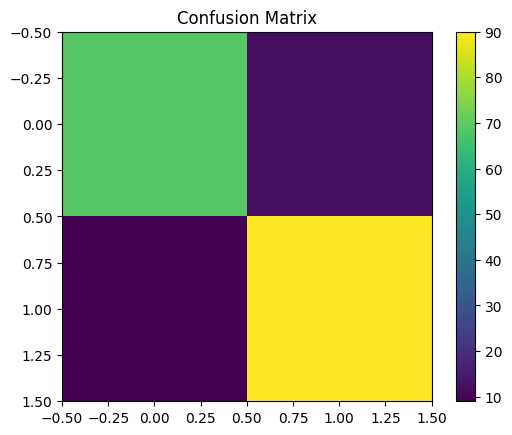

In [30]:
import matplotlib.pyplot as plt

plt.imshow(cm)

plt.colorbar()

plt.title(
    "Confusion Matrix"
)

plt.show()

18. Classification Report

In [31]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.88      0.85      0.87        81
           1       0.88      0.91      0.90        99

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



19. ROC-AUC Curve

In [32]:
rf_probs = rf.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    rf_probs
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9594089038533482


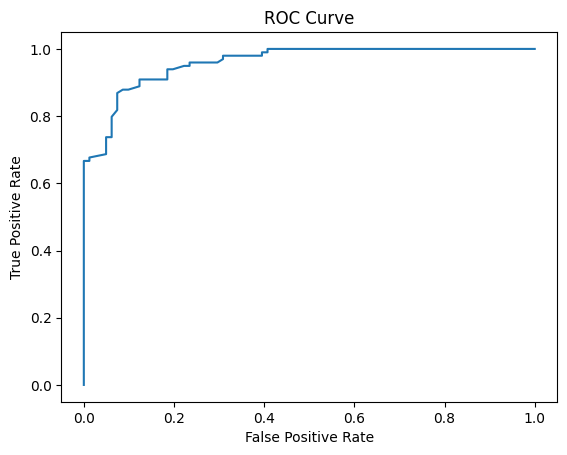

In [33]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

plt.plot(
    fpr,
    tpr
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.show()

20. Feature Importance

In [35]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf.feature_importances_
})

In [36]:
importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
10,ST_Slope,0.217398
2,ChestPainType,0.120104
4,Cholesterol,0.118150
9,Oldpeak,0.115813
7,MaxHR,0.105811
0,Age,0.088706
8,ExerciseAngina,0.073964
3,RestingBP,0.068985
1,Sex,0.039666
6,RestingECG,0.027351


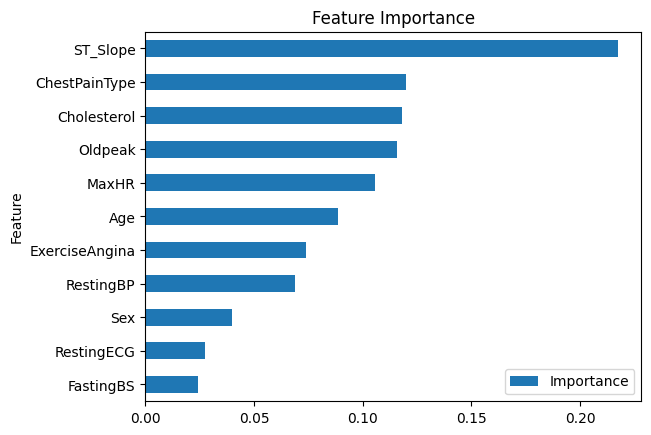

In [37]:
importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title(
    "Feature Importance"
)

plt.show()

21. Cross Validation

In [38]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(
    "CV Mean Accuracy:",
    cv_scores.mean()
)

CV Mean Accuracy: 0.826381129733085
